# 07 Audyt definicji targetu BWCI

Celem notebooka jest sprawdzenie, czy `event_threshold_10` jest stabilną i uczciwą definicją targetu dla dalszego modelowania.

Po notebooku 06 wiemy, że User 1 jest przypadkiem granicznym: obecny target progowy daje prawie zero pozytywnych przypadków, mimo że definicja dolnego kwartylu intuicyjnie powinna dawać około 25% obserwacji per użytkownik. Ten notebook wyjaśnia źródło problemu i porównuje warianty targetu.

Nie trenujemy tu modeli. Najpierw decydujemy, który target ma sens metodologiczny.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATASET_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1.parquet"
METADATA_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1_metadata.json"
TARGET_AUDIT_PATH = OUTPUT_DIR / "target_audit_event_threshold_10_v0_1.csv"
TARGET_VARIANTS_PATH = OUTPUT_DIR / "target_variants_event_threshold_10_v0_1.parquet"
TARGET_DECISION_PATH = OUTPUT_DIR / "target_decision_event_threshold_10_v0_1.json"

HORIZON = 10
CURRENT_TARGET = "event_threshold_10"
FUTURE_COL = "BWCI_future_10"
BWCI_COL = "BWCI_pu"
DROP_THRESHOLD = -0.15

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Wczytanie datasetu i kontrola obecnego targetu

Korzystamy z datasetu modelowego z notebooka 04, bo zawiera już `BWCI_pu`, `BWCI_future_10`, obecny target oraz splity czasowe.


In [2]:
if not DATASET_PATH.exists():
  raise FileNotFoundError(f"Missing model dataset: {DATASET_PATH}")
if not METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing metadata: {METADATA_PATH}")

model_dataset = pd.read_parquet(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text())

load_summary = pd.DataFrame(
  [
    {
      "rows": len(model_dataset),
      "users": model_dataset["USER"].nunique(),
      "current_target": CURRENT_TARGET,
      "current_positive_pct": model_dataset[CURRENT_TARGET].mean() * 100,
      "future_col": FUTURE_COL,
      "bwci_col": BWCI_COL,
    }
  ]
)
load_summary


,rows,users,current_target,current_positive_pct,future_col,bwci_col
0,76039,11,event_threshold_10,20.5644,BWCI_future_10,BWCI_pu


In [3]:
current_target_by_user = (
  model_dataset.groupby("USER")
  .agg(
    rows=(CURRENT_TARGET, "size"),
    positive_rows=(CURRENT_TARGET, "sum"),
    positive_pct=(CURRENT_TARGET, lambda values: values.mean() * 100),
    bwci_unique=(BWCI_COL, "nunique"),
    bwci_min=(BWCI_COL, "min"),
    bwci_q25=(BWCI_COL, lambda values: values.quantile(0.25)),
    bwci_median=(BWCI_COL, "median"),
  )
  .reset_index()
)
current_target_by_user


,USER,rows,positive_rows,positive_pct,bwci_unique,bwci_min,bwci_q25,bwci_median
0,0,5311,1328,25.0047,4700,0.1093,0.4057,0.4967
1,1,13450,2,0.0149,2758,0.1635,0.3270,0.5435
2,3,3136,782,24.9362,2747,0.1670,0.4101,0.4947
3,4,8110,2030,25.0308,7719,0.0117,0.4224,0.4994
4,5,1722,433,25.1452,1478,0.1607,0.3540,0.4785
5,6,982,248,25.2546,825,0.1043,0.3454,0.4895
6,7,3557,883,24.8243,3080,0.1829,0.4052,0.4996
7,8,4280,1066,24.9065,4089,0.1903,0.4131,0.4921
8,9,5745,1436,24.9956,5415,0.0778,0.4166,0.4964
9,10,12921,3223,24.9439,11926,0.0894,0.4045,0.4985


### Interpretacja obecnego targetu

Dla większości użytkowników obecny target działa zgodnie z intuicją: około 25% przyszłych obserwacji trafia poniżej dolnego kwartylu. User 1 jest wyjątkiem. To oznacza, że problem nie jest globalnym błędem przesunięcia `BWCI_future_10`, tylko specyficzną właściwością rozkładu BWCI dla jednego użytkownika.

Następna sekcja sprawdza, czy źródłem są remisy wartości `BWCI_pu` na progu kwartylowym.


## Sekcja 2: Remisy i próg kwartylowy

Obecna definicja używa warunku `BWCI_future_10 < q25_user`. Jeśli duża liczba obserwacji ma wartość dokładnie równą `q25`, warunek `<` może dać prawie zero pozytywów, a `<=` może dać ich zbyt dużo. To jest klasyczny problem dyskretnego/wiązaneego rozkładu.


In [4]:
def summarize_threshold_ties(df: pd.DataFrame) -> pd.DataFrame:
  """ Summarize tie behavior around the user-level q25 threshold.

    Args:
      df: Dataset containing USER, BWCI, and future BWCI columns.

    Returns:
      pd.DataFrame: Per-user threshold and tie diagnostics.
  """
  rows: list[dict[str, object]] = []
  for uid, user_df in df.groupby("USER"):
    q25 = user_df[BWCI_COL].quantile(0.25)
    future = user_df[FUTURE_COL]
    rows.append(
      {
        "USER": int(uid),
        "rows": len(user_df),
        "q25": q25,
        "future_lt_q25_pct": (future < q25).mean() * 100,
        "future_le_q25_pct": (future <= q25).mean() * 100,
        "future_eq_q25_pct": (future == q25).mean() * 100,
        "bwci_eq_q25_pct": (user_df[BWCI_COL] == q25).mean() * 100,
        "top_bwci_value": user_df[BWCI_COL].value_counts().index[0],
        "top_bwci_value_pct": user_df[BWCI_COL].value_counts(normalize=True).iloc[0] * 100,
      }
    )
  return pd.DataFrame(rows)


tie_summary = summarize_threshold_ties(model_dataset)
tie_summary


,USER,rows,q25,future_lt_q25_pct,future_le_q25_pct,future_eq_q25_pct,bwci_eq_q25_pct,top_bwci_value,top_bwci_value_pct
0,0,5311,0.4057,25.0047,25.0800,0.0753,0.0753,0.2605,0.3954
1,1,13450,0.3270,0.0149,40.9442,40.9294,40.9442,0.3270,40.9442
2,3,3136,0.4101,24.8406,24.8406,0.0000,0.0000,0.2423,0.5421
3,4,8110,0.4224,25.0801,25.0801,0.0000,0.0000,0.3291,0.1850
4,5,1722,0.3540,25.2613,25.4936,0.2323,0.2323,0.2912,0.5807
5,6,982,0.3454,25.3564,25.3564,0.0000,0.0000,0.2849,1.0183
6,7,3557,0.4052,24.8243,24.8524,0.0281,0.0281,0.3096,0.9559
7,8,4280,0.4131,25.0701,25.0701,0.0000,0.0000,0.3289,0.3972
8,9,5745,0.4166,24.9434,24.9608,0.0174,0.0174,0.3246,0.5570
9,10,12921,0.4045,24.9207,24.9284,0.0077,0.0077,0.2318,0.3173


In [5]:
user1 = model_dataset[model_dataset["USER"] == 1]
user1_value_counts = (
  user1[BWCI_COL]
  .value_counts()
  .rename_axis(BWCI_COL)
  .reset_index(name="count")
)
user1_value_counts["pct"] = user1_value_counts["count"] / len(user1) * 100
user1_value_counts.head(12)


,BWCI_pu,count,pct
0,0.3270,5507,40.9442
1,0.5451,2494,18.5428
2,0.6497,830,6.1710
3,0.4302,333,2.4758
4,0.5940,277,2.0595
5,0.6684,169,1.2565
6,0.6910,157,1.1673
7,0.6975,71,0.5279
8,0.6127,56,0.4164
9,0.6749,38,0.2825


### Interpretacja remisów

User 1 ma bardzo dużą masę prawdopodobieństwa dokładnie na wartości progowej. Warunek `< q25` prawie niczego nie oznacza jako pozytywne zdarzenie, a warunek `<= q25` oznaczałby zbyt dużą część obserwacji.

To jest mocny argument przeciwko prostemu targetowi `future < q25_user` jako finalnej definicji. Potrzebujemy wariantu odpornego na remisy.


## Sekcja 3: Konstrukcja wariantów targetu

Porównujemy warianty:

- `threshold_lt_full`: obecny target, `future < q25_user`,
- `threshold_le_full`: wariant `future <= q25_user`,
- `rank_bottom25_full`: dokładnie dolne 25% przyszłych obserwacji per użytkownik na podstawie rangi z rozstrzyganiem remisów kolejnością,
- `drop_10`: spadek przyszłego BWCI względem bieżącego o co najmniej `0.15`,
- `train_q25_lt`: próg q25 liczony tylko na train części danego użytkownika, a potem stosowany do wszystkich splitów,
- `train_rank_bottom25`: bottom 25% liczone osobno per split dla kontroli, jak target zachowuje się bez pełnej dystrybucji użytkownika.

`rank_bottom25_full` nie jest idealny, bo wymusza około 25% zdarzeń nawet przy remisach. Jest jednak stabilny jako target porównawczy i pokazuje, czy problem jest czysto techniczny.


In [6]:
def add_target_variants(df: pd.DataFrame) -> pd.DataFrame:
  """ Add alternative target definitions for BWCI future risk.

    Args:
      df: Dataset with BWCI and future BWCI columns.

    Returns:
      pd.DataFrame: Copy with target variants.
  """
  out = df.sort_values(["USER", "obs_idx"]).copy()
  user_q25 = out.groupby("USER")[BWCI_COL].transform(lambda values: values.quantile(0.25))
  out["threshold_lt_full"] = (out[FUTURE_COL] < user_q25).astype(int)
  out["threshold_le_full"] = (out[FUTURE_COL] <= user_q25).astype(int)
  out["drop_10"] = ((out[FUTURE_COL] - out[BWCI_COL]) <= DROP_THRESHOLD).astype(int)

  out["rank_bottom25_full"] = 0
  for _, idx in out.groupby("USER").groups.items():
    future = out.loc[idx, FUTURE_COL]
    n_positive = int(np.ceil(len(future) * 0.25))
    selected_idx = future.sort_values(kind="mergesort").index[:n_positive]
    out.loc[selected_idx, "rank_bottom25_full"] = 1

  train_thresholds = (
    out[out["temporal_split"] == "train"]
    .groupby("USER")[BWCI_COL]
    .quantile(0.25)
    .rename("train_q25")
  )
  out = out.merge(train_thresholds, on="USER", how="left")
  out["train_q25_lt"] = (out[FUTURE_COL] < out["train_q25"]).astype(int)

  out["train_rank_bottom25"] = 0
  for (_, split), idx in out.groupby(["USER", "temporal_split"]).groups.items():
    future = out.loc[idx, FUTURE_COL]
    n_positive = int(np.ceil(len(future) * 0.25))
    selected_idx = future.sort_values(kind="mergesort").index[:n_positive]
    out.loc[selected_idx, "train_rank_bottom25"] = 1
  return out


target_variants = add_target_variants(model_dataset)
target_cols = [
  "threshold_lt_full",
  "threshold_le_full",
  "rank_bottom25_full",
  "drop_10",
  "train_q25_lt",
  "train_rank_bottom25",
]

target_variant_summary = pd.DataFrame(
  [
    {
      "target": col,
      "positive_rows": int(target_variants[col].sum()),
      "positive_pct": target_variants[col].mean() * 100,
      "min_user_positive_pct": target_variants.groupby("USER")[col].mean().min() * 100,
      "max_user_positive_pct": target_variants.groupby("USER")[col].mean().max() * 100,
      "std_user_positive_pct": target_variants.groupby("USER")[col].mean().std() * 100,
    }
    for col in target_cols
  ]
)
target_variant_summary


,target,positive_rows,positive_pct,min_user_positive_pct,max_user_positive_pct,std_user_positive_pct
0,threshold_lt_full,15639,20.5671,0.0149,25.3564,7.5436
1,threshold_le_full,21156,27.8226,24.8406,40.9442,4.7920
2,rank_bottom25_full,19015,25.0069,25.0000,25.0509,0.0156
3,drop_10,11962,15.7314,12.5674,20.8178,2.8370
4,train_q25_lt,16155,21.2457,0.0149,32.9939,8.6204
5,train_rank_bottom25,19023,25.0174,25.0000,25.1527,0.0452


In [7]:
target_by_user_rows: list[dict[str, object]] = []
for col in target_cols:
  per_user = target_variants.groupby("USER")[col].agg(["size", "sum", "mean"]).reset_index()
  for _, row in per_user.iterrows():
    target_by_user_rows.append(
      {
        "target": col,
        "USER": int(row["USER"]),
        "rows": int(row["size"]),
        "positive_rows": int(row["sum"]),
        "positive_pct": row["mean"] * 100,
      }
    )

target_by_user = pd.DataFrame(target_by_user_rows)
target_by_user.pivot(index="USER", columns="target", values="positive_pct").round(3)


target,drop_10,rank_bottom25_full,threshold_le_full,threshold_lt_full,train_q25_lt,train_rank_bottom25
USER,,,,,,
0,14.1780,25.0050,25.0800,25.0050,24.4590,25.0240
1,20.8180,25.0040,40.9440,0.0150,0.0150,25.0110
3,15.0830,25.0000,24.8410,24.8410,22.3530,25.0320
4,13.7610,25.0060,25.0800,25.0800,24.1180,25.0180
5,20.7320,25.0290,25.4940,25.2610,22.1840,25.0870
6,15.3770,25.0510,25.3560,25.3560,32.9940,25.1530
7,15.1810,25.0210,24.8520,24.8240,24.0650,25.0210
8,12.7800,25.0000,25.0700,25.0700,30.4670,25.0000
9,12.5670,25.0130,24.9610,24.9430,23.0290,25.0300


### Interpretacja wariantów targetu

Najważniejszym kryterium na tym etapie nie jest jeszcze wynik modelu, tylko stabilność targetu per użytkownik. Target, który daje prawie zero pozytywów dla jednego użytkownika i około 25% dla reszty, będzie zniekształcał LOGO i utrudniał interpretację.

`rank_bottom25_full` i `train_rank_bottom25` są stabilne konstrukcyjnie. `drop_10` odpowiada innemu pytaniu: nie „czy przyszły stan jest niski”, tylko „czy nastąpił istotny spadek względem teraz”. To może być metodologicznie atrakcyjne dla ryzyka przerwania, ale nie jest tym samym targetem.


## Sekcja 4: Zgodność wariantów z obecnym targetem

Sprawdzamy, czy alternatywne targety oznaczają podobne obserwacje. Jeżeli targety są słabo zgodne, zmiana definicji nie jest kosmetyczna, tylko zmienia problem badawczy.


In [8]:
agreement_rows: list[dict[str, object]] = []
for col_a in target_cols:
  for col_b in target_cols:
    if col_a >= col_b:
      continue
    same = (target_variants[col_a] == target_variants[col_b]).mean() * 100
    both_pos = ((target_variants[col_a] == 1) & (target_variants[col_b] == 1)).sum()
    either_pos = ((target_variants[col_a] == 1) | (target_variants[col_b] == 1)).sum()
    jaccard = both_pos / either_pos if either_pos > 0 else np.nan
    agreement_rows.append(
      {
        "target_a": col_a,
        "target_b": col_b,
        "same_label_pct": same,
        "positive_jaccard": jaccard,
      }
    )

agreement_df = pd.DataFrame(agreement_rows).sort_values("positive_jaccard", ascending=False)
agreement_df


,target_a,target_b,same_label_pct,positive_jaccard
6,rank_bottom25_full,threshold_le_full,97.1133,0.8964
0,threshold_lt_full,train_q25_lt,97.4881,0.8867
5,rank_bottom25_full,threshold_lt_full,95.5181,0.8209
8,rank_bottom25_full,train_rank_bottom25,93.8979,0.7826
4,threshold_le_full,train_rank_bottom25,93.5204,0.7815
2,threshold_le_full,threshold_lt_full,92.7445,0.7392
7,rank_bottom25_full,train_q25_lt,93.0430,0.7385
14,train_q25_lt,train_rank_bottom25,92.6511,0.7258
1,threshold_lt_full,train_rank_bottom25,91.9305,0.6992
3,threshold_le_full,train_q25_lt,90.2353,0.6681


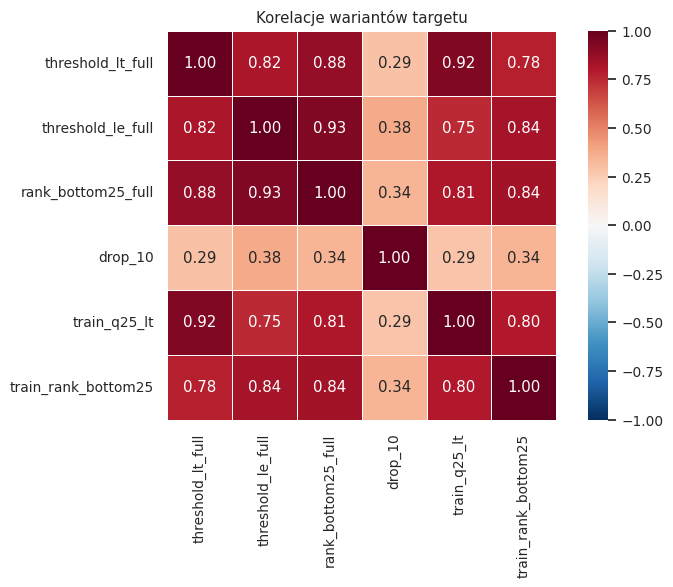

In [9]:
corr = target_variants[target_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Korelacje wariantów targetu")
fig.tight_layout()
plt.show()


### Interpretacja zgodności

Warianty progowe są ze sobą dość zgodne, ale różnice nie są kosmetyczne. `rank_bottom25_full` i `threshold_le_full` mają positive Jaccard (stosunek wspólnych pozytywów do unii obu targetów) `0.8964`, a `threshold_lt_full` i `train_q25_lt` `0.8867`, więc większość pozytywnych przypadków jest wspólna w obrębie podobnych definicji.

`drop_10` jest wyraźnie innym targetem. Jego positive Jaccard z wariantami progowymi wynosi tylko około `0.26-0.32`. To potwierdza, że `drop_10` nie jest drobną poprawką techniczną, lecz zmienia pytanie badawcze: z „czy przyszły stan jest niski" na „czy nastąpiło istotne pogorszenie względem teraz".

Wniosek: `drop_10` może być lepszy dla ryzyka przerwania, ale wyniki modeli dla `event_threshold_10` i `drop_10` nie powinny być przedstawiane jako bezpośrednio ten sam problem klasyfikacyjny.

## Sekcja 5: Konflikty etykiet przy identycznym przyszłym BWCI

Warianty rank-based rozwiązują problem częstości klasy pozytywnej, ale mogą wprowadzić inny problem: dwie obserwacje z tym samym `BWCI_future_10` mogą dostać różne etykiety tylko dlatego, że jedna z nich mieści się jeszcze w dolnych 25% po sortowaniu, a druga już nie.

Dla targetów opisujących absolutnie niski przyszły stan BWCI taka sytuacja jest metodologicznie niepożądana. Dla `drop_10` konflikt względem samego `BWCI_future_10` jest dopuszczalny, bo target zależy również od bieżącego `BWCI_pu`.


In [10]:
state_target_cols = ["threshold_lt_full", "threshold_le_full", "rank_bottom25_full", "train_q25_lt", "train_rank_bottom25"]
conflict_rows: list[dict[str, object]] = []
for col in target_cols:
  grouped = target_variants.groupby(["USER", FUTURE_COL])[col].agg(["nunique", "size"])
  conflicts = grouped[grouped["nunique"] > 1]
  conflict_rows.append(
    {
      "target": col,
      "state_target": col in state_target_cols,
      "conflict_groups": len(conflicts),
      "conflict_rows": int(conflicts["size"].sum()),
      "conflict_rows_pct": conflicts["size"].sum() / len(target_variants) * 100,
    }
  )

conflict_df = pd.DataFrame(conflict_rows)
conflict_df


,target,state_target,conflict_groups,conflict_rows,conflict_rows_pct
0,threshold_lt_full,True,0,0,0.0000
1,threshold_le_full,True,0,0,0.0000
2,rank_bottom25_full,True,2,5509,7.2450
3,drop_10,False,331,10324,13.5772
4,train_q25_lt,True,0,0,0.0000
5,train_rank_bottom25,True,22,5619,7.3896


### Interpretacja konfliktów

`rank_bottom25_full` i `train_rank_bottom25` są stabilne liczbowo, ale wprowadzają arbitralne rozstrzyganie remisów. Dla User 1 to jest poważne, bo ogromna liczba obserwacji ma identyczną wartość przyszłego BWCI na granicy progu.

Dlatego warianty rank-based są użyteczne diagnostycznie, ale nie powinny automatycznie stać się głównym targetem pracy. Stabilna częstość klasy pozytywnej nie wystarcza, jeśli identyczny przyszły stan może mieć różne etykiety.


## Sekcja 5: Stabilność w splitach czasowych

Target może być stabilny globalnie, ale nierówny między train, validation i test. Sprawdzamy positive rate per split dla każdego wariantu.


In [11]:
split_rows: list[dict[str, object]] = []
for col in target_cols:
  for split, split_df in target_variants.groupby("temporal_split"):
    split_rows.append(
      {
        "target": col,
        "split": split,
        "rows": len(split_df),
        "positive_rows": int(split_df[col].sum()),
        "positive_pct": split_df[col].mean() * 100,
      }
    )

split_target_summary = pd.DataFrame(split_rows)
split_target_summary.pivot(index="target", columns="split", values="positive_pct").round(3)


split,test,train,validation
target,,,
drop_10,15.9350,15.0040,17.7100
rank_bottom25_full,23.6330,26.5030,21.8930
threshold_le_full,30.8900,26.5180,28.6660
threshold_lt_full,23.5730,20.0350,19.1570
train_q25_lt,24.5070,20.5410,20.0970
train_rank_bottom25,25.0330,25.0100,25.0230


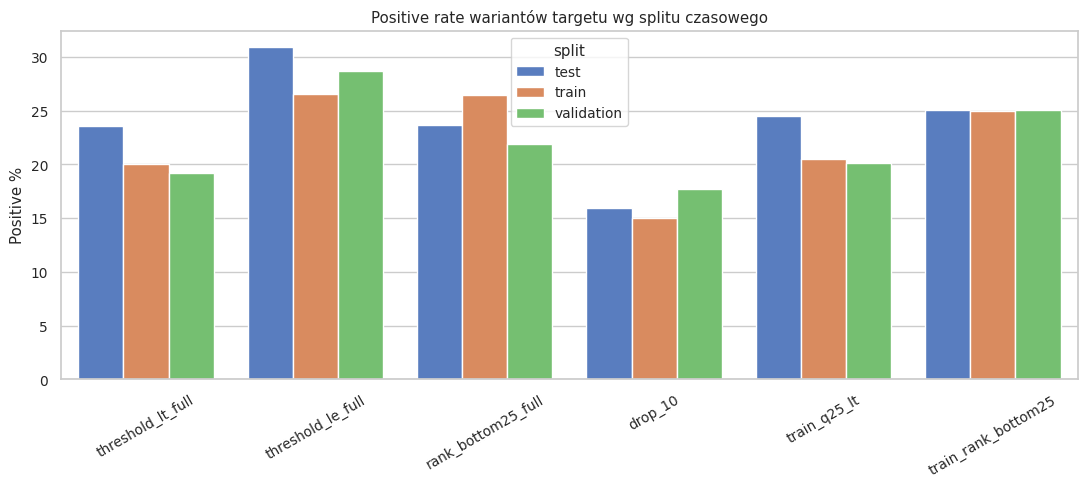

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=split_target_summary, x="target", y="positive_pct", hue="split", ax=ax)
ax.set_title("Positive rate wariantów targetu wg splitu czasowego")
ax.set_xlabel("")
ax.set_ylabel("Positive %")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


### Interpretacja splitów

`train_rank_bottom25` jest najbardziej stabilny między splitami, z zakresem positive rate tylko `0.0225 pp`, ale osiąga to przez arbitralne wymuszanie 25% pozytywów w każdym splicie. `rank_bottom25_full` ma idealną stabilność per user, ale większy zakres między splitami (`4.6105 pp`) i później okazuje się problematyczny przez konflikty remisów.

`drop_10` ma globalnie `15.73%` pozytywów i zakres między splitami `2.7061 pp`, co jest akceptowalne dla rzadszego zdarzenia pogorszenia. Co ważniejsze, nie tworzy prawie pustej klasy dla User 1.

`threshold_lt_full` i `train_q25_lt` pozostają problematyczne: oba mają prawie zerową klasę pozytywną dla User 1. `threshold_le_full` usuwa pustą klasę, ale podnosi User 1 do `40.94%` pozytywów, czyli mocno zmienia balans dla tego użytkownika.


## Sekcja 6: Prosta punktacja wariantów

Tworzymy roboczą punktację, żeby decyzja nie była wyłącznie opisowa. Kryteria:

- średni positive rate blisko 25% dla targetów progowych albo sensowny niezerowy rate dla `drop_10`,
- małe odchylenie positive rate między użytkownikami,
- brak użytkowników z prawie zerową liczbą pozytywów,
- brak ekstremalnej wrażliwości na remisy.


In [13]:
score_rows: list[dict[str, object]] = []
for col in target_cols:
  per_user = target_variants.groupby("USER")[col].mean() * 100
  split_rates = target_variants.groupby("temporal_split")[col].mean() * 100
  mean_positive = target_variants[col].mean() * 100
  min_user = per_user.min()
  max_user = per_user.max()
  std_user = per_user.std()
  split_range = split_rates.max() - split_rates.min()
  near_zero_users = int((per_user < 1).sum())
  near_half_users = int((per_user > 40).sum())
  conflict_pct = conflict_df.loc[conflict_df["target"] == col, "conflict_rows_pct"].iloc[0]

  if col == "drop_10":
    target_rate_penalty = abs(mean_positive - 15)
    exclusion_reason = ""
  elif col in ["rank_bottom25_full", "train_rank_bottom25"]:
    target_rate_penalty = abs(mean_positive - 25)
    exclusion_reason = "Arbitrary tie-breaking can assign different labels to identical future BWCI values."
  elif near_zero_users > 0:
    target_rate_penalty = abs(mean_positive - 25)
    exclusion_reason = "At least one user has an almost empty positive class."
  else:
    target_rate_penalty = abs(mean_positive - 25)
    exclusion_reason = ""

  score = 100 - (target_rate_penalty * 1.5) - (std_user * 2.0) - (split_range * 1.0) - (near_zero_users * 15) - (near_half_users * 10)
  if col in ["rank_bottom25_full", "train_rank_bottom25"]:
    score -= conflict_pct * 5

  score_rows.append(
    {
      "target": col,
      "mean_positive_pct": mean_positive,
      "min_user_positive_pct": min_user,
      "max_user_positive_pct": max_user,
      "std_user_positive_pct": std_user,
      "split_rate_range_pct": split_range,
      "near_zero_users": near_zero_users,
      "over_40pct_users": near_half_users,
      "conflict_rows_pct": conflict_pct,
      "eligible_as_primary": exclusion_reason == "",
      "exclusion_reason": exclusion_reason,
      "heuristic_score": score,
    }
  )

score_df = pd.DataFrame(score_rows).sort_values(["eligible_as_primary", "heuristic_score"], ascending=[False, False])
score_df


,target,mean_positive_pct,min_user_positive_pct,max_user_positive_pct,std_user_positive_pct,split_rate_range_pct,near_zero_users,over_40pct_users,conflict_rows_pct,eligible_as_primary,exclusion_reason,heuristic_score
3,drop_10,15.7314,12.5674,20.8178,2.8370,2.7061,0,0,13.5772,True,,90.5228
1,threshold_le_full,27.8226,24.8406,40.9442,4.7920,4.3716,0,1,0.0000,True,,71.8106
5,train_rank_bottom25,25.0174,25.0000,25.1527,0.0452,0.0225,0,0,7.3896,False,Arbitrary tie-breaking can assign different la...,62.9128
2,rank_bottom25_full,25.0069,25.0000,25.0509,0.0156,4.6105,0,0,7.2450,False,Arbitrary tie-breaking can assign different la...,59.1232
0,threshold_lt_full,20.5671,0.0149,25.3564,7.5436,4.4166,1,0,0.0000,False,At least one user has an almost empty positive...,58.8469
4,train_q25_lt,21.2457,0.0149,32.9939,8.6204,4.4096,1,0,0.0000,False,At least one user has an almost empty positive...,57.7181


### Interpretacja punktacji

Ta punktacja nie jest testem statystycznym ani formalnym wyborem modelu. Jest uporządkowanym audytem ryzyka definicji targetu.

Po dodaniu kontroli konfliktów rank-based warianty nie powinny być traktowane jako automatycznie najlepsze, mimo idealnego balansu klas. `threshold_lt_full` i `train_q25_lt` odpadają przez prawie pustą klasę pozytywną dla User 1. `threshold_le_full` jest dopuszczalnym wariantem „niski przyszły stan”, ale mocno zwiększa positive rate dla User 1. `drop_10` najlepiej pasuje semantycznie do ryzyka przerwania, bo mierzy pogorszenie względem obecnego stanu i nie opiera się na arbitralnym rozstrzyganiu remisów kwartylowych.


## Sekcja 7: Rekomendacja robocza

Na podstawie audytu wybieramy rekomendowany target do kolejnej iteracji notebooków 04-06. Decyzja pozostaje robocza, ale powinna być wystarczająco jasna, żeby przebudować dataset modelowy.


In [14]:
recommended_target = "drop_10"
secondary_low_state_target = "threshold_le_full"
recommendation = {
  "recommended_primary_target": recommended_target,
  "previous_primary_target": CURRENT_TARGET,
  "secondary_low_state_target": secondary_low_state_target,
  "reason": "drop_10 is recommended as the primary interruption-risk target because it avoids the User 1 q25 tie failure and directly represents future deterioration.",
  "why_not_rank_bottom25": "Rank-based variants stabilize prevalence but can assign different labels to identical future BWCI values when ties occur.",
  "why_not_threshold_lt": "The strict q25 target creates an almost empty positive class for User 1.",
  "keep_as_sensitivity": [col for col in target_cols if col != recommended_target],
  "important_caution": "drop_10 measures deterioration risk, not simply low future BWCI. Report threshold_le_full as a sensitivity target for low-state risk.",
}

recommendation_df = pd.DataFrame([recommendation])
recommendation_df


,recommended_primary_target,previous_primary_target,secondary_low_state_target,reason,why_not_rank_bottom25,why_not_threshold_lt,keep_as_sensitivity,important_caution
0,drop_10,event_threshold_10,threshold_le_full,drop_10 is recommended as the primary interrup...,Rank-based variants stabilize prevalence but c...,The strict q25 target creates an almost empty ...,"[threshold_lt_full, threshold_le_full, rank_bo...","drop_10 measures deterioration risk, not simpl..."


### Decyzja po audycie

Rekomendacja po audycie zmienia główny target klasyfikacyjny z `event_threshold_10` na `drop_10` dla kolejnej iteracji modelowania. To jest świadoma zmiana interpretacji: z „przyszły stan jest w dolnym kwartylu” na „nastąpiło istotne pogorszenie ciągłości względem obecnego stanu”.

Ta druga interpretacja jest bliższa ryzyku przerwania pracy i unika problemu User 1. `threshold_le_full` warto zachować jako wariant wrażliwości dla pytania o niski przyszły stan. Warianty rank-based zostają diagnostyczne, ale nie są rekomendowane jako target główny przez arbitralne rozstrzyganie remisów.


## Sekcja 8: Zapis artefaktów

Zapisujemy audyt i warianty targetu do `outputs/`, żeby kolejny notebook mógł odtworzyć decyzję bez przepisywania logiki.


In [15]:
target_audit = target_by_user.merge(
  score_df[["target", "heuristic_score", "mean_positive_pct", "std_user_positive_pct", "split_rate_range_pct"]],
  on="target",
  how="left",
)

target_audit.to_csv(TARGET_AUDIT_PATH, index=False)
target_variants.to_parquet(TARGET_VARIANTS_PATH, index=False)
TARGET_DECISION_PATH.write_text(json.dumps(recommendation, ensure_ascii=False, indent=2))

print(f"Saved target audit: {TARGET_AUDIT_PATH}")
print(f"Saved target variants: {TARGET_VARIANTS_PATH}")
print(f"Saved target decision: {TARGET_DECISION_PATH}")


Saved target audit: /home/sefni/git/bwci-thesis/outputs/target_audit_event_threshold_10_v0_1.csv
Saved target variants: /home/sefni/git/bwci-thesis/outputs/target_variants_event_threshold_10_v0_1.parquet
Saved target decision: /home/sefni/git/bwci-thesis/outputs/target_decision_event_threshold_10_v0_1.json


## Decyzje dla kolejnego etapu

Audyt wskazuje `drop_10` jako najlepszy roboczy target dla ryzyka przerwania/pogorszenia, a `threshold_le_full` jako wariant wrażliwości dla pytania o niski przyszły stan BWCI. `threshold_lt_full` i `train_q25_lt` odpadają jako targety główne przez prawie pustą klasę pozytywną dla User 1. Warianty rank-based zostają diagnostyczne, ale nie finalne, bo rozstrzygają remisy arbitralnie.

Następny krok nie powinien być tuningiem. Najpierw trzeba sprawdzić, jak modele zachowują się na `drop_10` przy tej samej logice temporal split i LOGO. Dopiero po tym można przebudować czystą ścieżkę pipeline pod finalny target.
